# 📊 Customer Segmentation & Sales Analysis

This project analyzes real-world e-commerce transaction data to understand customer behavior, sales trends, and business insights using Python.

In [44]:
!pip install pd
import pandas as pd

## 📁 Data Loading & Overview

In this step, we load the dataset and explore its structure to understand the available features such as customer ID, invoice details, product information, and pricing.

In [45]:
df=pd.read_excel("Online+Retail.xlsx")

In [46]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [47]:
df.shape

(541909, 8)

In [48]:
df.columns

Index(['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'UnitPrice', 'CustomerID', 'Country'],
      dtype='object')

In [49]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[ns]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 33.1+ MB


In [50]:
df.describe()

,Quantity,InvoiceDate,UnitPrice,CustomerID
count,541909.000000,541909,541909.000000,406829.000000
mean,9.552250,2011-07-04 13:34:57.156386048,4.611114,15287.690570
min,-80995.000000,2010-12-01 08:26:00,-11062.060000,12346.000000
25%,1.000000,2011-03-28 11:34:00,1.250000,13953.000000
50%,3.000000,2011-07-19 17:17:00,2.080000,15152.000000
75%,10.000000,2011-10-19 11:27:00,4.130000,16791.000000
max,80995.000000,2011-12-09 12:50:00,38970.000000,18287.000000
std,218.081158,NaN,96.759853,1713.600303


## 🧹 Data Cleaning

Data cleaning is performed to ensure accuracy and reliability of analysis.

Steps performed:
- Removed missing values
- Filtered out cancelled orders (InvoiceNo starting with 'C')
- Converted InvoiceDate to proper datetime format

In [51]:
df.dropna()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
...,...,...,...,...,...,...,...,...
541904,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,2011-12-09 12:50:00,0.85,12680.0,France
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09 12:50:00,2.10,12680.0,France
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,4.15,12680.0,France
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.15,12680.0,France


In [52]:
df = df[~df['InvoiceNo'].astype(str).str.startswith('C')].copy()

In [53]:
df.loc['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

## ⚙️ Feature Engineering

New features are created to enhance analysis:

- **TotalPrice** = Quantity × UnitPrice
- Extracted **Month** and **Year** from InvoiceDate

These features help in understanding revenue trends and time-based patterns.

In [54]:
df['TotalPrice'] = df['Quantity'] * df['UnitPrice']

In [55]:
df['Month'] = df['InvoiceDate'].dt.month
df['Year'] = df['InvoiceDate'].dt.year

## 📊 Customer Analysis

This section focuses on understanding customer behavior:

- Identified top customers based on total spending
- Calculated number of unique customers
- Analyzed country-wise sales distribution

In [56]:
top_customers = df.groupby('CustomerID')['TotalPrice'].sum().sort_values(ascending=False).head(10)
print(top_customers)

CustomerID
14646.0    280206.02
18102.0     259657.3
17450.0    194550.79
16446.0     168472.5
14911.0    143825.06
12415.0    124914.53
14156.0    117379.63
17511.0     91062.38
16029.0     81024.84
12346.0      77183.6
Name: TotalPrice, dtype: object


In [57]:
top_customers = df.groupby('CustomerID')['TotalPrice'].sum().sort_values(ascending=False).head(10)
print(top_customers)

CustomerID
14646.0    280206.02
18102.0     259657.3
17450.0    194550.79
16446.0     168472.5
14911.0    143825.06
12415.0    124914.53
14156.0    117379.63
17511.0     91062.38
16029.0     81024.84
12346.0      77183.6
Name: TotalPrice, dtype: object


In [58]:
unique_customers = df['CustomerID'].nunique()
print(unique_customers)

4339


## 📈 Data Visualization

Visualizations are used to present insights clearly:

- Bar Chart → Top 10 customers by spending
- Pie Chart → Country-wise sales distribution
- Line Chart → Monthly sales trend

These charts help in understanding patterns and business performance.

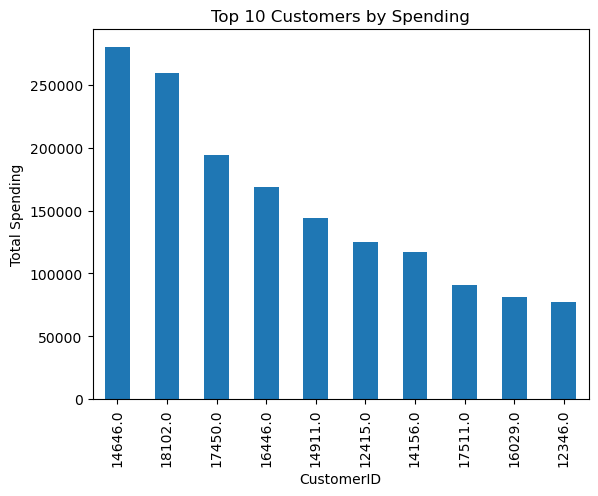

In [59]:
import matplotlib.pyplot as plt

top_customers.plot(kind='bar')
plt.title("Top 10 Customers by Spending")
plt.xlabel("CustomerID")
plt.ylabel("Total Spending")
plt.show() 

In [60]:
country_sales = df.groupby('Country')['TotalPrice'].sum().sort_values(ascending=False)

C:\Users\DURGA DAMAI\AppData\Local\Temp\ipykernel_15700\1649739143.py:1: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  country_sales.head(5).plot(kind='pie', autopct='%1.1f%%')


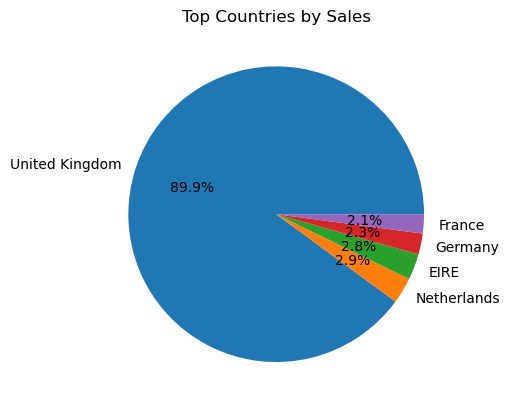

In [61]:
country_sales.head(5).plot(kind='pie', autopct='%1.1f%%')
plt.title("Top Countries by Sales")
plt.ylabel('')
plt.show()

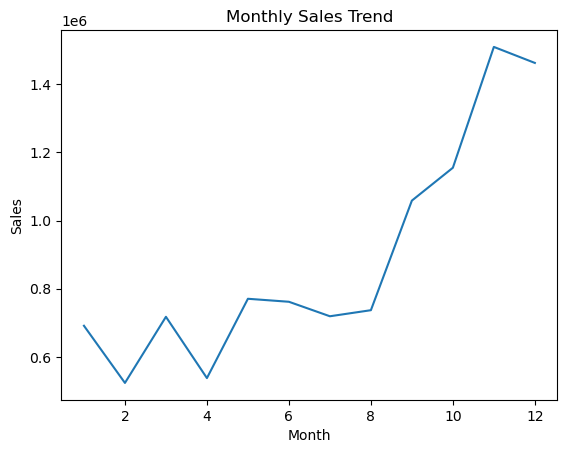

In [62]:
monthly_sales = df.groupby('Month')['TotalPrice'].sum()

monthly_sales.plot(kind='line')
plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Sales")
plt.show()

## 🔥 RFM Analysis (Customer Segmentation)

RFM analysis is used to evaluate customer value:

- **Recency** → How recently a customer made a purchase
- **Frequency** → How often they purchase
- **Monetary** → How much they spend

This helps in identifying high-value and loyal customers.

In [63]:
import datetime as dt

reference_date = df['InvoiceDate'].max() + dt.timedelta(days=1)

rfm = df.groupby('CustomerID').agg({
    'InvoiceDate': lambda x: (reference_date - x.max()).days,  # Recency
    'InvoiceNo': 'nunique',  # Frequency
    'TotalPrice': 'sum'  # Monetary
})

rfm.columns = ['Recency', 'Frequency', 'Monetary']
rfm.head()

,Recency,Frequency,Monetary
CustomerID,,,
12346.0,326,1,77183.6
12347.0,2,7,4310.0
12348.0,75,4,1797.24
12349.0,19,1,1757.55
12350.0,310,1,334.4


In [64]:
print(rfm.columns)

Index(['Recency', 'Frequency', 'Monetary'], dtype='object')


In [65]:
rfm = rfm.reset_index()

## 🤖 Customer Segmentation using K-Means

After performing RFM analysis, we apply K-Means clustering to segment customers into distinct groups based on their purchasing behavior.

### Steps involved:
- Feature scaling using StandardScaler
- Finding optimal clusters using Elbow Method
- Applying K-Means clustering
- Labeling customer segments

This helps in identifying:
- High-value customers
- Medium-value customers
- Low-value customers

In [66]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm[['Recency','Frequency','Monetary']])

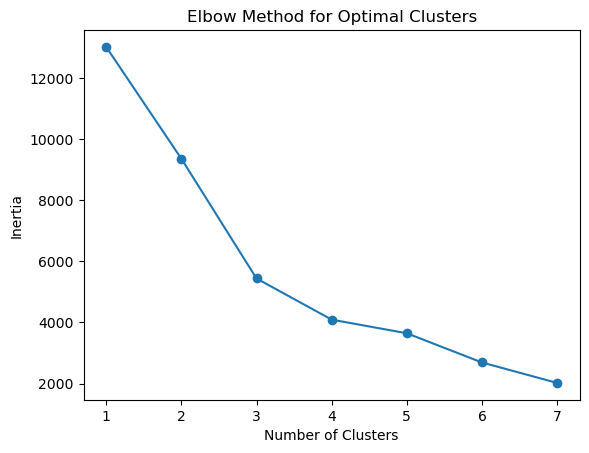

In [67]:
from sklearn.cluster import KMeans
kmeans = KMeans(n_clusters=3, random_state=42)
rfm['Cluster'] = kmeans.fit_predict(rfm_scaled)
import matplotlib.pyplot as plt

inertia = []

for k in range(1, 8):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(rfm_scaled)
    inertia.append(kmeans.inertia_)

plt.plot(range(1, 8), inertia, marker='o')
plt.title("Elbow Method for Optimal Clusters")
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.show()

In [68]:
df['CustomerID'] = df['CustomerID'].astype(str)
rfm['CustomerID'] = rfm['CustomerID'].astype(str)

In [69]:
df = df.merge(rfm[['CustomerID', 'Cluster']], on='CustomerID', how='left')

In [70]:
kmeans = KMeans(n_clusters=3, random_state=42)
rfm['Cluster'] = kmeans.fit_predict(rfm_scaled) 

In [71]:
def segment_label(cluster):
    if cluster == 0:
        return "High Value"
    elif cluster == 1:
        return "Mid Value"
    else:
        return "Low Value"

rfm['Segment'] = rfm['Cluster'].apply(segment_label)


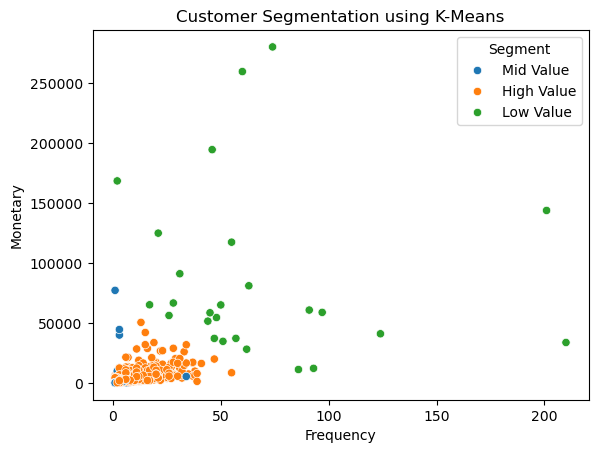

In [72]:
import seaborn as sns

sns.scatterplot(data=rfm, x='Frequency', y='Monetary', hue='Segment')
plt.title("Customer Segmentation using K-Means")
plt.show()

## 📊 Business Questions

- Which segment generates the most revenue?
- Which customers are at risk of churn?
- Which month had the highest sales and why?
- Which country contributes the most to revenue?
- How can we improve low-value customer segments?

## 📊 Segment-Level Analysis

To better understand customer behavior, we analyzed each cluster based on revenue, customer count, and average spending.

- Revenue per cluster helps identify high-value segments
- Customer count shows distribution across segments
- Average spending indicates purchasing power of each group

In [73]:
# Revenue per cluster
revenue_cluster = df.groupby('Cluster')['TotalPrice'].sum().sort_values(ascending=False)
print(revenue_cluster)

# Number of customers per cluster
customers_cluster = df.groupby('Cluster')['CustomerID'].nunique()
print(customers_cluster)

# Average spending per cluster
avg_spending = df.groupby('Cluster')['TotalPrice'].mean()
print(avg_spending)

Cluster
0.0    5994693.773002
2.0        2233513.14
1.0        683200.991
Name: TotalPrice, dtype: object
Cluster
0.0    3231
1.0    1082
2.0      26
Name: CustomerID, dtype: int64
Cluster
0.0    18.403026
1.0      21.9298
2.0    54.442733
Name: TotalPrice, dtype: object


## 📈 Visualizations

- Bar Chart → Revenue generated by each cluster  
- Pie Chart → Distribution of customers across clusters  
- Box Plot → Spending behavior within each cluster  

These visualizations help in identifying high-value, mid-value, and low-value customer segments.

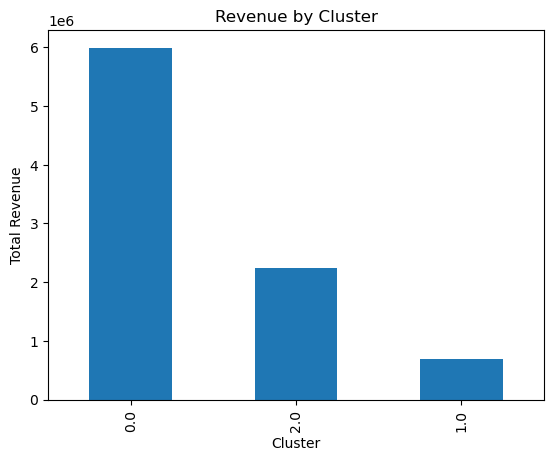

In [74]:
import matplotlib.pyplot as plt

revenue_cluster.plot(kind='bar')
plt.title("Revenue by Cluster")
plt.xlabel("Cluster")
plt.ylabel("Total Revenue")
plt.show()

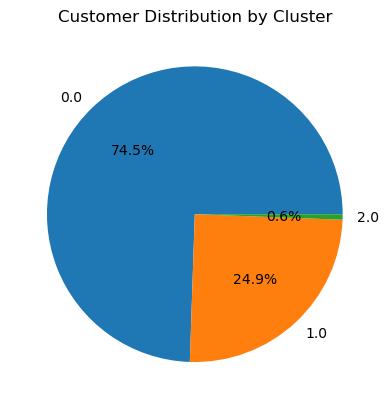

In [75]:
customers_cluster.plot(kind='pie', autopct='%1.1f%%')
plt.title("Customer Distribution by Cluster")
plt.ylabel('')
plt.show()

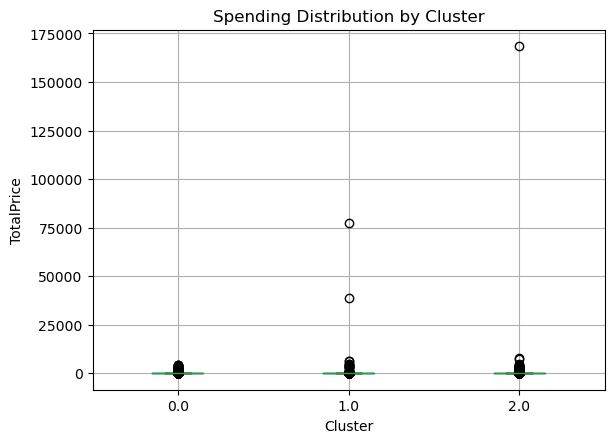

In [76]:
df.boxplot(column='TotalPrice', by='Cluster')
plt.title("Spending Distribution by Cluster")
plt.suptitle('')
plt.xlabel("Cluster")
plt.ylabel("TotalPrice")
plt.show()

## 💡 Key Insights

- A small segment of customers contributes a disproportionately large share of total revenue, reinforcing the importance of identifying and retaining high-value customers.

- Sales are concentrated in specific countries, indicating strong geographic markets that can be further leveraged for targeted marketing strategies.

- Monthly sales trends show noticeable fluctuations, suggesting the presence of seasonal demand patterns that businesses can plan around.

- Customers with higher purchase frequency tend to generate significantly greater revenue, highlighting the importance of customer retention and repeat engagement.

- RFM analysis helped classify customers based on recency, frequency, and monetary value, enabling a deeper understanding of customer behavior.

- K-Means clustering further grouped customers into distinct segments such as high-value, mid-value, and low-value customers, making it easier to design personalized marketing strategies.

- Cluster-level analysis revealed:
High-value clusters contribute the largest share of revenue despite smaller size
Low-value clusters contain more customers but lower spending
Mid-value customers represent growth potential if properly targeted
- Visualization of clusters (bar charts, pie charts, box plots) clearly shows imbalanced revenue distribution and customer segmentation patterns


## 🚀 Conclusion

This project demonstrates how combining Exploratory Data Analysis, RFM modeling, K-Means clustering, and cluster-level analysis can transform raw transactional data into meaningful business insights.

By leveraging Python, Pandas, and data visualization techniques, we moved from basic data cleaning to advanced customer segmentation, identifying not just who the customers are, but how valuable they are to the business. 
The integration of RFM and clustering provides a powerful framework for:

Identifying high-value customers
Understanding purchasing behavior
Segmenting customers into actionable groups

These insights enable businesses to implement data-driven strategies such as personalized marketing, targeted promotions, customer retention programs, and efficient resource allocation.

Overall, this project highlights the importance of turning data into decisions, helping businesses maximize revenue while building stronger customer relationships.

## 📊 Customer Lifetime Value (CLTV)

In this step, we calculate the Customer Lifetime Value (CLTV) to estimate how much revenue each customer generates.

CLTV helps identify high-value customers and supports better business decision-making.

In [77]:
# Average purchase value per customer
avg_purchase_value = df.groupby('CustomerID')['TotalPrice'].mean()

# Purchase frequency (number of invoices)
purchase_frequency = df.groupby('CustomerID')['InvoiceNo'].nunique()

# CLTV calculation (simple version)
cltv = avg_purchase_value * purchase_frequency

# Create CLTV DataFrame
cltv_df = pd.DataFrame({
    'CustomerID': cltv.index,
    'CLTV': cltv.values
})

# CLTV Segments
cltv_df['CLTV_Segment'] = pd.qcut(cltv_df['CLTV'], q=3, labels=['Low CLTV', 'Mid CLTV', 'High CLTV'])

## 🔗 Merging Customer Data

Here, we combine RFM metrics, cluster labels, and CLTV into a single dataset.

This unified dataset allows us to analyze customer behavior, value, and segmentation together.

In [78]:
# Merge RFM + Cluster + CLTV
final_df = rfm.merge(cltv_df, on='CustomerID', how='left')

## 🤖 Customer Strategy Engine

In this step, we build a rule-based strategy engine that assigns a business action to each customer.

The strategy is based on:
- Customer segment (Cluster)
- Customer value (CLTV Segment)

This helps transform data insights into actionable business decisions.

In [79]:
def strategy(row):
    
    # High Value + High CLTV
    if row['Cluster'] == 0 and row['CLTV_Segment'] == 'High CLTV':
        return "VIP Retention (Loyalty rewards, exclusive offers)"
    
    # Mid Value + High CLTV
    elif row['Cluster'] == 1 and row['CLTV_Segment'] == 'High CLTV':
        return "Upsell Opportunity (Premium product recommendations)"
    
    # Mid Value + Mid CLTV
    elif row['Cluster'] == 1:
        return "Nurture Customers (Email marketing, engagement campaigns)"
    
    # Low Value + Low CLTV
    elif row['Cluster'] == 2 and row['CLTV_Segment'] == 'Low CLTV':
        return "Re-engagement (Discounts, offers, reminders)"
    
    # Default
    else:
        return "General Marketing"

## ⚙️ Applying Business Strategies

We apply the strategy function to each customer to generate personalized recommendations.

Each customer will now have a defined strategy such as:
- VIP Retention
- Upsell Opportunity
- Re-engagement

In [80]:
final_df['Strategy'] = final_df.apply(strategy, axis=1)

In [81]:
final_df['Strategy'].value_counts()

Strategy
General Marketing                                            1983
VIP Retention (Loyalty rewards, exclusive offers)            1274
Nurture Customers (Email marketing, engagement campaigns)     936
Upsell Opportunity (Premium product recommendations)          146
Name: count, dtype: int64

## 📊 Strategy Analysis

Now we analyze how customers are distributed across different strategies.

This helps understand:
- Which strategies dominate
- Where most revenue comes from

In [82]:
df = df.merge(final_df[['CustomerID', 'Strategy']], on='CustomerID', how='left')

revenue_strategy = df.groupby('Strategy')['TotalPrice'].sum().sort_values(ascending=False)
print(revenue_strategy)

Strategy
VIP Retention (Loyalty rewards, exclusive offers)              4521153.4
General Marketing                                            3707053.513
Nurture Customers (Email marketing, engagement campaigns)     369516.431
Upsell Opportunity (Premium product recommendations)           313684.56
Name: TotalPrice, dtype: object


## 📈 Visualization

We visualize the distribution of strategies and revenue contribution to better understand the business impact of each segment.

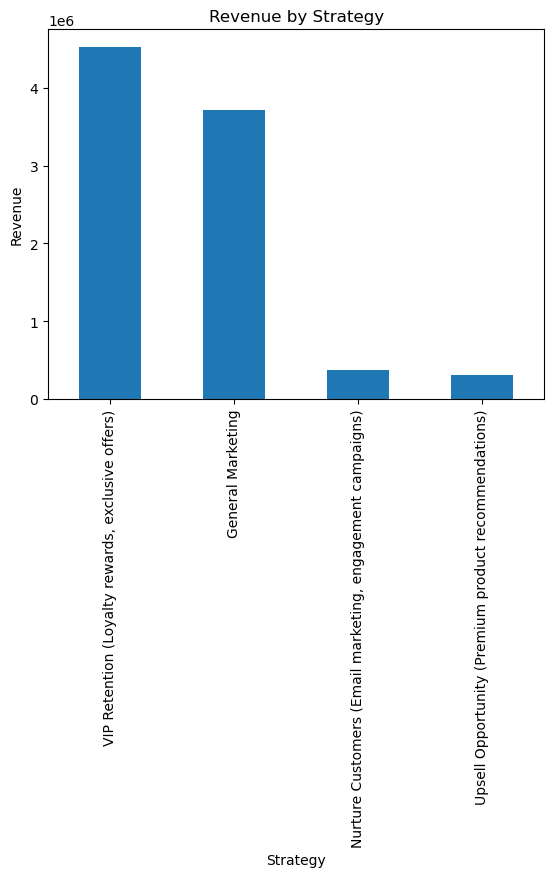

In [83]:
import matplotlib.pyplot as plt

revenue_strategy.plot(kind='bar', title='Revenue by Strategy')
plt.xlabel("Strategy")
plt.ylabel("Revenue")
plt.show()

## 📁 Exporting Final Dataset

Finally, we export the dataset containing customer segments, CLTV, and recommended strategies.

This dataset can be used for dashboards (Power BI) or further business analysis.

In [84]:
final_df.to_csv("customer_strategy_data.csv", index=False)